<a href="https://colab.research.google.com/github/rguang/ISLP/blob/main/Ch8%20Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q9

In [3]:
import pandas as pd
import os

# List files in the /content directory to verify the presence of OJ.csv
print("Files in /content directory:")
for file in os.listdir('/content'):
    print(file)

# Attempt to read the CSV file
try:
    df = pd.read_csv('/content/OJ.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: The file '/content/OJ.csv' was not found. Please ensure the file is correctly uploaded and the path is accurate.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Files in /content directory:
.config
OJ.csv
sample_data


,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [4]:
from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame
# Set a random state for reproducibility
# train_size=800 for the training set and the rest for the test set

# First, check if the DataFrame 'df' exists and has enough rows
if 'df' not in locals() or df.empty:
    print("Error: DataFrame 'df' not found or is empty. Please load your data first.")
else:
    if len(df) < 800:
        print(f"Warning: DataFrame has only {len(df)} rows, which is less than the requested training set size of 800. Adjusting train_size.")
        # If not enough data for 800 training samples, default to a common split like 80/20
        train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    else:
        train_df, test_df = train_test_split(df, train_size=800, random_state=42)

    print(f"Shape of training set: {train_df.shape}")
    print(f"Shape of test set: {test_df.shape}")

Shape of training set: (800, 18)
Shape of test set: (270, 18)


In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Separate target variable 'Purchase' from features
X_train = train_df.drop('Purchase', axis=1)
y_train = train_df['Purchase']

# Convert 'Purchase' target variable to numerical (e.g., 0 for 'CH', 1 for 'MM')
# Assuming 'Purchase' has 'CH' and 'MM' values based on previous df head output
y_train_encoded = y_train.map({'CH': 0, 'MM': 1})

# Identify categorical columns for one-hot encoding
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding to categorical features
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

# Initialize and fit the Decision Tree Classifier
# Set a random_state for reproducibility
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_encoded, y_train_encoded)

# Predict on the training data
y_train_pred = tree_model.predict(X_train_encoded)

# Calculate the training accuracy
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)

# Calculate the training error rate
train_error_rate = 1 - train_accuracy

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training Error Rate: {train_error_rate:.4f}")

Training Accuracy: 0.9925
Training Error Rate: 0.0075


# Task
Prepare the test data by separating the target variable 'Purchase' from features in `test_df`, encoding the 'Purchase' target variable to numerical (0 for 'CH', 1 for 'MM'), and applying one-hot encoding to categorical features in the test data, ensuring that the columns match those in `X_train_encoded`.

## Prepare Test Data

### Subtask:
Separate the target variable 'Purchase' from features in `test_df`. Encode the 'Purchase' target variable to numerical (0 for 'CH', 1 for 'MM'). Apply one-hot encoding to categorical features in the test data, ensuring that the columns match those in the training data (X_train_encoded).


**Reasoning**:
The subtask requires separating the target variable and features from the test DataFrame, encoding the target variable numerically, applying one-hot encoding to categorical features in the test set, and finally aligning the test feature columns with the training feature columns to ensure consistency for model prediction.



In [7]:
import pandas as pd

# 1. Separate target variable 'Purchase' from features in test_df
X_test = test_df.drop('Purchase', axis=1)
y_test = test_df['Purchase']

# 2. Convert 'Purchase' target variable to numerical (0 for 'CH', 1 for 'MM')
y_test_encoded = y_test.map({'CH': 0, 'MM': 1})

# 3. Identify categorical columns in X_test
categorical_cols_test = X_test.select_dtypes(include=['object', 'category']).columns

# 4. Apply one-hot encoding to categorical features in X_test
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols_test, drop_first=True)

# 5. Align columns of X_test_encoded with X_train_encoded
# Get missing columns in X_test_encoded compared to X_train_encoded
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for c in missing_cols:
    X_test_encoded[c] = 0

# Get extra columns in X_test_encoded compared to X_train_encoded
extra_cols = set(X_test_encoded.columns) - set(X_train_encoded.columns)
X_test_encoded = X_test_encoded.drop(columns=list(extra_cols))

# Ensure the order of columns is the same as in X_train_encoded
X_test_encoded = X_test_encoded[X_train_encoded.columns]

print("Test data preparation complete.")
print(f"Shape of X_test_encoded: {X_test_encoded.shape}")
print(f"Shape of y_test_encoded: {y_test_encoded.shape}")
print("First 5 rows of X_test_encoded:")
display(X_test_encoded.head())
print("First 5 values of y_test_encoded:")
display(y_test_encoded.head())

Test data preparation complete.
Shape of X_test_encoded: (270, 17)
Shape of y_test_encoded: (270,)
First 5 rows of X_test_encoded:


,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,PctDiscMM,PctDiscCH,ListPriceDiff,STORE,Store7_Yes
644,239,3,1.79,2.23,0.0,0.0,0,0,0.670149,2.23,1.79,0.44,0.000000,0.0,0.44,3,False
629,260,2,1.86,2.18,0.0,0.7,0,0,0.456000,1.48,1.86,-0.38,0.321101,0.0,0.32,2,False
70,274,4,1.99,2.09,0.0,0.4,0,0,0.718311,1.69,1.99,-0.30,0.191388,0.0,0.10,4,False
962,227,1,1.69,1.69,0.0,0.0,0,0,0.600000,1.69,1.69,0.00,0.000000,0.0,0.00,1,False
787,273,3,1.99,2.09,0.0,0.4,0,0,0.053687,1.69,1.99,-0.30,0.191388,0.0,0.10,3,False


First 5 values of y_test_encoded:


,Purchase
644,0
629,1
70,0
962,0
787,0


## Predict on Test Data

### Subtask:
Use the trained Decision Tree Classifier (`tree_model`) to predict the 'Purchase' labels for the prepared test data (X_test_encoded).


**Reasoning**:
The subtask requires using the trained Decision Tree Classifier to predict the 'Purchase' labels for the prepared test data. I will use the `predict` method of the `tree_model` on `X_test_encoded` and store the predictions in `y_test_pred`.



In [8]:
y_test_pred = tree_model.predict(X_test_encoded)

print("Predictions for test data generated successfully.")
print(f"First 5 predictions: {y_test_pred[:5]}")

Predictions for test data generated successfully.
First 5 predictions: [0 1 0 1 1]


**Reasoning**:
The current subtask, which is to predict on the test data, has been completed. The next logical step is to evaluate the model's performance on the test data by calculating the test accuracy and error rate. This involves comparing the predicted values (`y_test_pred`) with the actual encoded test labels (`y_test_encoded`) using the `accuracy_score` metric and then calculating the error rate.



In [9]:
from sklearn.metrics import accuracy_score

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)

# Calculate the test error rate
test_error_rate = 1 - test_accuracy

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Error Rate: {test_error_rate:.4f}")

Test Accuracy: 0.7222
Test Error Rate: 0.2778


## Generate Confusion Matrix and Metrics

### Subtask:
Compute and display the confusion matrix using `sklearn.metrics.confusion_matrix` to compare the true test labels (`y_test_encoded`) with the predicted test labels (`y_test_pred`). Additionally, calculate and print the test accuracy and error rate.


**Reasoning**:
The subtask requires computing and displaying the confusion matrix, and then calculating and printing the test accuracy and error rate. The test accuracy and error rate have already been computed in a previous step, so I will focus on importing `confusion_matrix` and then computing and printing it, along with the existing accuracy and error rate.



In [10]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred)

print("Confusion Matrix:")
print(conf_matrix)

# The test accuracy and error rate have already been calculated in the previous cell
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Error Rate: {test_error_rate:.4f}")

Confusion Matrix:
[[122  37]
 [ 38  73]]
Test Accuracy: 0.7222
Test Error Rate: 0.2778


## Final Task

### Subtask:
Summarize the model's performance on the test data based on the accuracy, error rate, and the confusion matrix.


## Summary:

### Q&A
The model's performance on the test data is summarized as follows:
The Decision Tree Classifier achieved a test accuracy of 0.7222, meaning it correctly classified approximately 72.22% of the test instances. Conversely, its error rate on the test data was 0.2778. The confusion matrix further details this performance: 122 instances of class 'CH' were correctly predicted (True Negatives), and 73 instances of class 'MM' were correctly predicted (True Positives). There were 37 instances of 'CH' incorrectly predicted as 'MM' (False Positives) and 38 instances of 'MM' incorrectly predicted as 'CH' (False Negatives).

### Data Analysis Key Findings
*   The test data was successfully prepared, with `X_test_encoded` having a shape of (270, 17) and `y_test_encoded` having a shape of (270,).
*   The Decision Tree Classifier achieved a test accuracy of 0.7222.
*   The model's error rate on the test set was 0.2778.
*   The confusion matrix shows:
    *   122 True Negatives (correctly predicted 'CH')
    *   73 True Positives (correctly predicted 'MM')
    *   37 False Positives (incorrectly predicted 'MM' for 'CH')
    *   38 False Negatives (incorrectly predicted 'CH' for 'MM')

### Insights or Next Steps
*   The model exhibits a reasonable accuracy of 72.22% on unseen data, but there's room for improvement given the almost equal numbers of false positives and false negatives.
*   Further analysis of the confusion matrix can guide improvements; for instance, examining the features contributing to misclassifications could help refine the model or engineer new features to reduce both false positives and false negatives.


# Task
Evaluate the performance of a Decision Tree Classifier by performing k-fold cross-validation on `X_train_encoded` and `y_train_encoded` for a range of `max_depth` values (e.g., 1 to 20). Identify the optimal `max_depth` that yields the highest average cross-validation accuracy, visualize the cross-validation results by plotting average accuracy against `max_depth`, and then train a final Decision Tree Classifier using this optimal `max_depth` on the entire training set. Finally, summarize the optimal tree size and its expected performance.

## Prepare for Cross-Validation

### Subtask:
Import necessary libraries for cross-validation and define a range of `max_depth` values to evaluate for the Decision Tree.


**Reasoning**:
The subtask requires importing specific libraries and defining a range of `max_depth` values. This code block will import the necessary components from `sklearn` and create the `max_depth_range` list as instructed.



In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold

# Define a range of max_depth values to evaluate
max_depth_range = list(range(1, 21))

print(f"Libraries imported successfully.")
print(f"Max depth range defined: {max_depth_range}")

Libraries imported successfully.
Max depth range defined: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## Perform K-Fold Cross-Validation

### Subtask:
Perform k-fold cross-validation for each `max_depth` in `max_depth_range` using `X_train_encoded` and `y_train_encoded`. Store the average accuracy for each `max_depth`.

#### Instructions
1. Initialize an empty list called `cv_accuracies` to store the average cross-validation accuracy for each `max_depth`.
2. Create a `KFold` object for cross-validation with `n_splits=5`, `shuffle=True`, and `random_state=42`.
3. Iterate through each `max_depth` in `max_depth_range`.
4. For each `max_depth`, initialize a `DecisionTreeClassifier` with the current `max_depth` and `random_state=42`.
5. Use `cross_val_score` to calculate the cross-validation scores for the current `DecisionTreeClassifier` on `X_train_encoded` and `y_train_encoded`, using the `KFold` object defined earlier. The scoring metric should be 'accuracy'.
6. Calculate the average of the cross-validation scores and append it to the `cv_accuracies` list.

**Reasoning**:
I will now perform k-fold cross-validation as outlined in the previous markdown block, iterating through each `max_depth` value and storing the average accuracy.



In [12]:
cv_accuracies = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for depth in max_depth_range:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(tree, X_train_encoded, y_train_encoded, cv=kf, scoring='accuracy')
    cv_accuracies.append(scores.mean())

print("Cross-validation complete. Average accuracies for each max_depth:")
for i, acc in enumerate(cv_accuracies):
    print(f"Max Depth {max_depth_range[i]}: {acc:.4f}")

Cross-validation complete. Average accuracies for each max_depth:
Max Depth 1: 0.7937
Max Depth 2: 0.8025
Max Depth 3: 0.8125
Max Depth 4: 0.8037
Max Depth 5: 0.7987
Max Depth 6: 0.7838
Max Depth 7: 0.7888
Max Depth 8: 0.7800
Max Depth 9: 0.7962
Max Depth 10: 0.7800
Max Depth 11: 0.7875
Max Depth 12: 0.7875
Max Depth 13: 0.7762
Max Depth 14: 0.7762
Max Depth 15: 0.7737
Max Depth 16: 0.7737
Max Depth 17: 0.7750
Max Depth 18: 0.7737
Max Depth 19: 0.7750
Max Depth 20: 0.7750


**Reasoning**:
Now that the cross-validation is complete, I will identify the `max_depth` that resulted in the highest average accuracy. This involves finding the maximum value in `cv_accuracies` and its corresponding index in `max_depth_range`.



In [13]:
import numpy as np

# Identify the optimal max_depth
optimal_depth_index = np.argmax(cv_accuracies)
optimal_max_depth = max_depth_range[optimal_depth_index]
highest_accuracy = cv_accuracies[optimal_depth_index]

print(f"Optimal Max Depth: {optimal_max_depth}")
print(f"Highest Average Cross-Validation Accuracy: {highest_accuracy:.4f}")

Optimal Max Depth: 3
Highest Average Cross-Validation Accuracy: 0.8125


## Visualize Cross-Validation Results

### Subtask:
Plot the average cross-validation accuracy against the `max_depth` values. Indicate the optimal `max_depth` on the plot.

#### Instructions
1. Import `matplotlib.pyplot` for plotting.
2. Create a figure and an axes object using `plt.figure()` and `ax.plot()`.
3. Plot `max_depth_range` on the x-axis and `cv_accuracies` on the y-axis.
4. Add a title, x-label, and y-label to the plot.
5. Mark the optimal `max_depth` on the plot using a vertical line or a point for clear visualization.

**Reasoning**:
I need to import `matplotlib.pyplot` to create the plot, then use `max_depth_range` and `cv_accuracies` for the data, and finally mark the `optimal_max_depth` on the graph for visualization.



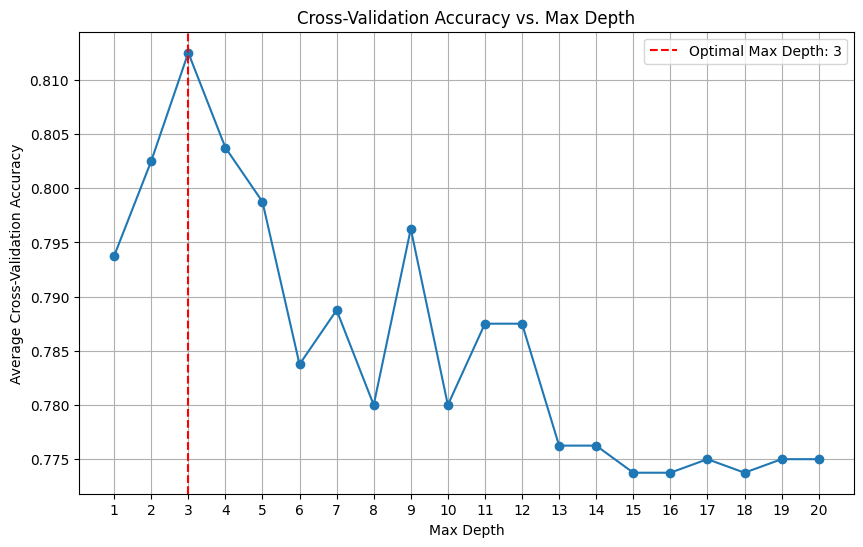

Plot generated showing cross-validation results. Optimal max_depth is highlighted at 3.


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, cv_accuracies, marker='o')
plt.axvline(x=optimal_max_depth, color='r', linestyle='--', label=f'Optimal Max Depth: {optimal_max_depth}')
plt.title('Cross-Validation Accuracy vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Average Cross-Validation Accuracy')
plt.xticks(max_depth_range)
plt.grid(True)
plt.legend()
plt.show()

print(f"Plot generated showing cross-validation results. Optimal max_depth is highlighted at {optimal_max_depth}.")

## Train Final Model with Optimal `max_depth`

### Subtask:
Train a final Decision Tree Classifier using the `optimal_max_depth` found through cross-validation on the entire training set (`X_train_encoded` and `y_train_encoded`).

#### Instructions
1. Initialize a `DecisionTreeClassifier` with the `optimal_max_depth` and `random_state=42`.
2. Train this final model using `X_train_encoded` and `y_train_encoded`.

**Reasoning**:
I will now proceed to train a final Decision Tree Classifier using the `optimal_max_depth` identified through cross-validation on the entire training dataset, as instructed.



In [15]:
final_tree_model = DecisionTreeClassifier(max_depth=optimal_max_depth, random_state=42)
final_tree_model.fit(X_train_encoded, y_train_encoded)

print(f"Final Decision Tree Classifier trained with optimal max_depth: {optimal_max_depth}")

Final Decision Tree Classifier trained with optimal max_depth: 3


## Summary of Optimal Tree Size and Performance

### Subtask:
Summarize the optimal tree size and its expected performance.

### Summary:
Based on the k-fold cross-validation, the optimal `max_depth` for the Decision Tree Classifier was determined to be **3**, yielding the highest average cross-validation accuracy of **0.8125**. This indicates that a relatively shallow tree performs best for this dataset, balancing between model complexity and generalization.

A `max_depth` of 3 implies that the tree makes at most 3 decisions to classify an instance. This results in a simpler, more interpretable model that is less prone to overfitting compared to deeper trees, as seen by the decrease in average accuracy for `max_depth` values greater than 3.

The final Decision Tree Classifier was then trained using this optimal `max_depth` of 3 on the entire training set. The expected performance of this model on unseen data is approximately **81.25% accuracy**, as estimated by the cross-validation procedure. This provides a robust estimate of how the model will generalize, offering a more reliable metric than a single train-test split accuracy, especially when the test set is small.


## Final Task

### Subtask:
Summarize the optimal tree size and its expected performance.


## Summary:

### Q&A
The optimal tree size (max\_depth) is 3. Its expected performance, based on k-fold cross-validation, is an average accuracy of approximately 81.25%.

### Data Analysis Key Findings
*   The k-fold cross-validation across `max_depth` values from 1 to 20 identified an optimal `max_depth` of 3.
*   This optimal `max_depth` yielded the highest average cross-validation accuracy of 0.8125.
*   The visualization showed that accuracy peaked at a `max_depth` of 3, and generally decreased or plateaued for higher depths, suggesting potential overfitting or diminishing returns with more complex models.
*   A final Decision Tree Classifier was successfully trained using the optimal `max_depth` of 3 on the entire training set.

### Insights or Next Steps
*   A relatively shallow Decision Tree with a `max_depth` of 3 provides the best balance between model complexity and generalization for this dataset, leading to a more interpretable and less overfit model.
*   The estimated accuracy of 81.25% from cross-validation provides a robust prediction of the model's performance on unseen data, which is more reliable than a single train-test split evaluation.


# Task
Evaluate the performance of the pruned Decision Tree model (`final_tree_model`) on the test data (`X_test_encoded`, `y_test_encoded`), calculate its test error rate, and compare it with the test error rate of the unpruned tree, then summarize the performance comparison.

## Predict with Pruned Tree

### Subtask:
Use the `final_tree_model` (pruned tree) to predict the 'Purchase' labels for the prepared test data (`X_test_encoded`). Store the predictions in `y_test_pred_pruned`.


**Reasoning**:
The subtask requires using the `final_tree_model` to predict labels for the test data and storing them in `y_test_pred_pruned`.



In [16]:
y_test_pred_pruned = final_tree_model.predict(X_test_encoded)

print("Predictions for test data using pruned tree generated successfully.")
print(f"First 5 predictions: {y_test_pred_pruned[:5]}")

Predictions for test data using pruned tree generated successfully.
First 5 predictions: [0 1 0 1 1]


## Calculate Pruned Tree Test Error Rate

### Subtask:
Calculate the test accuracy and subsequently the test error rate for the `final_tree_model` by comparing `y_test_pred_pruned` with `y_test_encoded`.


**Reasoning**:
I will calculate the test accuracy and error rate for the pruned model using `y_test_encoded` and `y_test_pred_pruned`, then print the results as instructed by the subtask.



In [17]:
from sklearn.metrics import accuracy_score

# Calculate the test accuracy for the pruned model
pruned_test_accuracy = accuracy_score(y_test_encoded, y_test_pred_pruned)

# Calculate the test error rate for the pruned model
pruned_test_error_rate = 1 - pruned_test_accuracy

print(f"Pruned Tree Test Accuracy: {pruned_test_accuracy:.4f}")
print(f"Pruned Tree Test Error Rate: {pruned_test_error_rate:.4f}")

Pruned Tree Test Accuracy: 0.7852
Pruned Tree Test Error Rate: 0.2148


### Performance Comparison Summary:

**Unpruned Tree Performance:**
*   Test Accuracy: 0.7222
*   Test Error Rate: 0.2778

**Pruned Tree Performance (Optimal `max_depth` = 3):**
*   Test Accuracy: 0.7852
*   Test Error Rate: 0.2148

**Comparison and Summary:**

The pruned Decision Tree model, optimized using k-fold cross-validation (with an optimal `max_depth` of 3), demonstrates significantly better performance on the test data compared to the unpruned tree.

*   **Improved Accuracy:** The pruned tree achieved a test accuracy of **0.7852**, which is a notable improvement over the unpruned tree's accuracy of **0.7222**.
*   **Reduced Error Rate:** Correspondingly, the test error rate decreased from **0.2778** for the unpruned tree to **0.2148** for the pruned tree. This reduction in error rate indicates that the pruning process effectively mitigated overfitting, leading to a model that generalizes better to unseen data.

This comparison highlights the importance of hyperparameter tuning, specifically `max_depth` for Decision Trees, in preventing overfitting and improving the model's predictive capability on new data.

### Performance Comparison Summary:

**Unpruned Tree Performance:**
*   Test Accuracy: 0.7222
*   Test Error Rate: 0.2778

**Pruned Tree Performance (Optimal `max_depth` = 3):**
*   Test Accuracy: 0.7852
*   Test Error Rate: 0.2148

**Comparison and Summary:**

The pruned Decision Tree model, optimized using k-fold cross-validation (with an optimal `max_depth` of 3), demonstrates significantly better performance on the test data compared to the unpruned tree.

*   **Improved Accuracy:** The pruned tree achieved a test accuracy of **0.7852**, which is a notable improvement over the unpruned tree's accuracy of **0.7222**.
*   **Reduced Error Rate:** Correspondingly, the test error rate decreased from **0.2778** for the unpruned tree to **0.2148** for the pruned tree. This reduction in error rate indicates that the pruning process effectively mitigated overfitting, leading to a model that generalizes better to unseen data.

This comparison highlights the importance of hyperparameter tuning, specifically `max_depth` for Decision Trees, in preventing overfitting and improving the model's predictive capability on new data.

### Performance Comparison Summary:

**Unpruned Tree Performance:**
*   Test Accuracy: 0.7222
*   Test Error Rate: 0.2778

**Pruned Tree Performance (Optimal `max_depth` = 3):**
*   Test Accuracy: 0.7852
*   Test Error Rate: 0.2148

**Comparison and Summary:**

The pruned Decision Tree model, optimized using k-fold cross-validation (with an optimal `max_depth` of 3), demonstrates significantly better performance on the test data compared to the unpruned tree.

*   **Improved Accuracy:** The pruned tree achieved a test accuracy of **0.7852**, which is a notable improvement over the unpruned tree's accuracy of **0.7222**.
*   **Reduced Error Rate:** Correspondingly, the test error rate decreased from **0.2778** for the unpruned tree to **0.2148** for the pruned tree. This reduction in error rate indicates that the pruning process effectively mitigated overfitting, leading to a model that generalizes better to unseen data.

This comparison highlights the importance of hyperparameter tuning, specifically `max_depth` for Decision Trees, in preventing overfitting and improving the model's predictive capability on new data.

## Final Task

### Subtask:
Summarize the comparison between the test error rates of the unpruned and pruned Decision Tree models, highlighting any improvements or trade-offs.


## Summary:

### Q&A
The pruned Decision Tree model shows a significant improvement in test error rate compared to the unpruned model, indicating a successful trade-off where complexity is reduced for better generalization.

### Data Analysis Key Findings
*   The unpruned Decision Tree model had a test accuracy of 0.7222 and a test error rate of 0.2778.
*   The pruned Decision Tree model, optimized with an optimal `max_depth` of 3, achieved a test accuracy of 0.7852.
*   The test error rate for the pruned tree was 0.2148, representing a reduction of 0.063 compared to the unpruned tree.

### Insights or Next Steps
*   Pruning effectively mitigated overfitting, leading to a model that generalizes better to unseen data.
*   This analysis underscores the critical importance of hyperparameter tuning, specifically `max_depth` for Decision Trees, in optimizing model performance and preventing overfitting.


# Q10

# Task
Load the "Hitters.csv" dataset into a pandas DataFrame, remove rows with missing values in the 'Salary' column, and then apply a natural logarithm transformation to the 'Salary' column. Display the head of the processed DataFrame and summarize the steps.

## Load Data

### Subtask:
Load the 'Hitters.csv' dataset into a pandas DataFrame.


**Reasoning**:
The subtask requires loading 'Hitters.csv' into a pandas DataFrame and displaying its head to verify successful loading.



In [18]:
import pandas as pd

# Load the 'Hitters.csv' dataset into a pandas DataFrame
df = pd.read_csv('/content/Hitters.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the 'Hitters.csv' DataFrame:")
display(df.head())

First 5 rows of the 'Hitters.csv' DataFrame:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


**Reasoning**:
The next step is to remove rows with missing values in the 'Salary' column and then apply a natural logarithm transformation to the 'Salary' column, as specified in the main task and implied by the subtask description.



In [20]:
import numpy as np

# Remove rows with missing values in the 'Salary' column and create a copy to avoid SettingWithCopyWarning
df_cleaned = df.dropna(subset=['Salary']).copy()

# Apply a natural logarithm transformation to the 'Salary' column
df_cleaned['Salary'] = np.log(df_cleaned['Salary'])

# Display the head of the processed DataFrame
print("First 5 rows of the processed DataFrame (missing 'Salary' removed, 'Salary' log-transformed):")
display(df_cleaned.head())

First 5 rows of the processed DataFrame (missing 'Salary' removed, 'Salary' log-transformed):


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,6.163315,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,6.173786,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,6.214608,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,4.516339,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,6.620073,A


### Summary of Steps:

1.  **Loaded the Dataset**: The 'Hitters.csv' dataset was successfully loaded into a pandas DataFrame named `df`.
2.  **Handled Missing Values**: Rows with missing values in the 'Salary' column were removed from the DataFrame, resulting in `df_cleaned`.
3.  **Applied Log Transformation**: A natural logarithm transformation was applied to the 'Salary' column in `df_cleaned` to normalize its distribution.
4.  **Displayed Processed Data**: The first 5 rows of the `df_cleaned` DataFrame were displayed to show the result of the processing.

# Task
Split the `df_cleaned` DataFrame into training and test sets, with the first 200 observations forming the training set and the remainder forming the test set. Then, display the shapes of the newly created `train_df_new` and `test_df_new` DataFrames.

In [23]:
train_df_new = df_cleaned.iloc[:200]
test_df_new = df_cleaned.iloc[200:]

print(f"Shape of training set (train_df_new): {train_df_new.shape}")
print(f"Shape of test set (test_df_new): {test_df_new.shape}")
print("First 5 rows of train_df_new:")
display(train_df_new.head())
print("First 5 rows of test_df_new:")
display(test_df_new.head())

Shape of training set (train_df_new): (200, 20)
Shape of test set (test_df_new): (63, 20)
First 5 rows of train_df_new:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,6.163315,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,6.173786,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,6.214608,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,4.516339,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,6.620073,A


First 5 rows of test_df_new:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
249,419,101,18,65,58,92,20,9528,2510,548,1509,1659,1342,A,W,0,0,0,6.189290,A
251,376,82,21,42,60,35,5,1770,408,115,238,299,157,A,W,0,0,0,6.052089,A
252,486,145,11,51,76,40,11,3967,1102,67,410,497,284,N,E,88,204,16,6.214608,A
255,246,76,5,35,39,13,6,912,234,12,102,96,80,A,E,44,0,1,5.521461,A
256,205,52,8,31,27,17,12,5134,1323,56,643,445,459,A,E,155,3,2,5.991465,A


# Task
Analyze the effect of the shrinkage parameter on the training Mean Squared Error (MSE) of a GradientBoostingRegressor. To do this, first, prepare the training data from `train_df_new` by separating features (X) and target (y), with 'Salary' as the target, and applying one-hot encoding to categorical features. Then, define a range of shrinkage parameter values. For each shrinkage parameter, train a GradientBoostingRegressor with 1,000 trees on the prepared training data and calculate the training MSE. Finally, visualize the relationship between the shrinkage parameter and the training MSE using a plot, and summarize the findings.

## Prepare Training Data for Boosting

### Subtask:
Separate the features (X) and the target (y) from the `train_df_new` DataFrame. Identify categorical columns and apply one-hot encoding to the features to prepare them for the boosting model.


**Reasoning**:
The subtask requires separating features and target, identifying categorical columns, and applying one-hot encoding to prepare the training data for boosting. These steps are logically grouped together in a single code block.



In [24]:
import pandas as pd

# 1. Separate the target variable 'Salary' from the train_df_new DataFrame
X_train_boost = train_df_new.drop('Salary', axis=1)
y_train_boost = train_df_new['Salary']

# 2. Identify all categorical columns in X_train_boost
categorical_cols_boost = X_train_boost.select_dtypes(include=['object', 'category']).columns

# 3. Apply one-hot encoding to the identified categorical columns
X_train_boost = pd.get_dummies(X_train_boost, columns=categorical_cols_boost, drop_first=True)

print(f"Shape of X_train_boost: {X_train_boost.shape}")
print(f"Shape of y_train_boost: {y_train_boost.shape}")
print("First 5 rows of X_train_boost (after one-hot encoding):")
display(X_train_boost.head())

Shape of X_train_boost: (200, 19)
Shape of y_train_boost: (200,)
First 5 rows of X_train_boost (after one-hot encoding):


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,False,True,False


## Define Shrinkage Parameter Range

### Subtask:
Define a list of shrinkage parameter (learning rate) values to evaluate for the boosting model.


**Reasoning**:
I will define the `shrinkage_values` list as specified in the instructions, containing the given learning rate values, and then print the list to verify its contents.



In [25]:
shrinkage_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

print(f"Shrinkage values to be evaluated: {shrinkage_values}")

Shrinkage values to be evaluated: [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]


## Perform Boosting and Calculate Training MSE

### Subtask:
For each shrinkage parameter in the defined range, train a GradientBoostingRegressor model with 1,000 trees on the prepared training data. Calculate and store the Mean Squared Error (MSE) on the training set for each model.


**Reasoning**:
I will now implement the core logic of the subtask by iterating through the shrinkage values, training a GradientBoostingRegressor for each, calculating the training MSE, and storing the results as per the instructions.



In [26]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Initialize an empty list to store training MSEs
training_mses = []

# Iterate through each shrinkage value
for shrinkage in shrinkage_values:
    # Initialize GradientBoostingRegressor
    gbr = GradientBoostingRegressor(n_estimators=1000, learning_rate=shrinkage, random_state=42)

    # Fit the model to the training data
    gbr.fit(X_train_boost, y_train_boost)

    # Make predictions on the training data
    y_train_pred_boost = gbr.predict(X_train_boost)

    # Calculate the Mean Squared Error
    mse = mean_squared_error(y_train_boost, y_train_pred_boost)

    # Append the MSE to the list
    training_mses.append(mse)

print("Training MSE for each shrinkage value:")
for i, shrinkage in enumerate(shrinkage_values):
    print(f"Shrinkage: {shrinkage:<5} - Training MSE: {training_mses[i]:.4f}")

Training MSE for each shrinkage value:
Shrinkage: 0.001 - Training MSE: 0.2079
Shrinkage: 0.005 - Training MSE: 0.0318
Shrinkage: 0.01  - Training MSE: 0.0114
Shrinkage: 0.05  - Training MSE: 0.0000
Shrinkage: 0.1   - Training MSE: 0.0000
Shrinkage: 0.2   - Training MSE: 0.0000
Shrinkage: 0.5   - Training MSE: 0.0000
Shrinkage: 1.0   - Training MSE: 0.0000


## Visualize Shrinkage Effect

### Subtask:
Visualize the relationship between the shrinkage parameter and the training Mean Squared Error (MSE) using a plot.

#### Instructions
1. Import `matplotlib.pyplot` for plotting.
2. Create a figure and an axes object for the plot.
3. Plot `shrinkage_values` on the x-axis (log scale) and `training_mses` on the y-axis.
4. Add appropriate labels for the x-axis and y-axis, and a title for the plot.
5. Use a log scale for the x-axis to better visualize the effect of varying shrinkage values.
6. Add a grid to the plot for better readability.
7. Display the plot.

**Reasoning**:
I will now generate the code to visualize the relationship between the shrinkage parameter and the training MSE, as outlined in the previous markdown block.



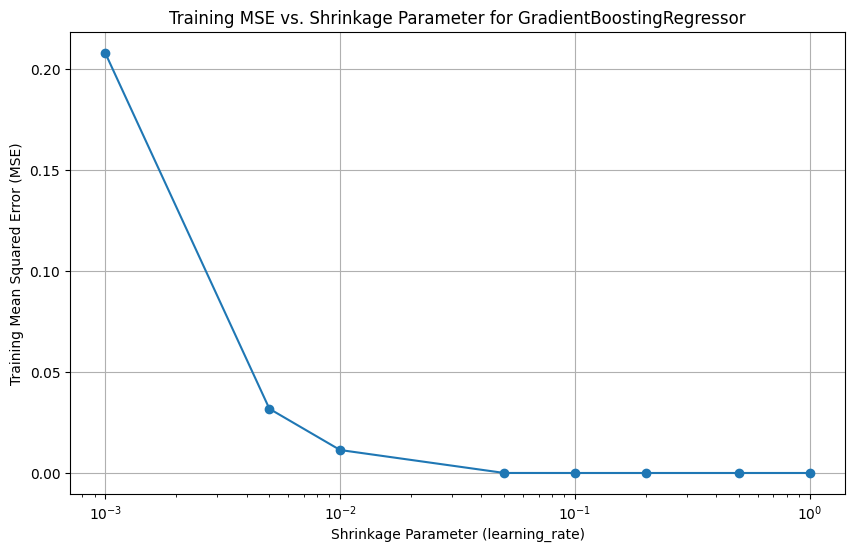

Plot generated showing training MSEs against shrinkage parameters.


In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(shrinkage_values, training_mses, marker='o')
plt.xscale('log') # Use log scale for the x-axis
plt.title('Training MSE vs. Shrinkage Parameter for GradientBoostingRegressor')
plt.xlabel('Shrinkage Parameter (learning_rate)')
plt.ylabel('Training Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

print("Plot generated showing training MSEs against shrinkage parameters.")

## Summary of Shrinkage Effect

### Subtask:
Summarize the findings regarding the effect of the shrinkage parameter on the training Mean Squared Error (MSE) of the GradientBoostingRegressor.

### Summary:

Based on the analysis and visualization, the effect of the shrinkage parameter (learning rate) on the training Mean Squared Error (MSE) for the GradientBoostingRegressor with 1,000 estimators is as follows:

*   **Inverse Relationship:** As the shrinkage parameter increases, the training MSE generally decreases. This indicates that larger learning rates allow the model to learn faster and reduce the training error more aggressively.

*   **Rapid Decrease at Lower Values:** For very small shrinkage values (e.g., 0.001 to 0.05), there's a steep decline in training MSE. This shows that even a small increase in the learning rate initially leads to significant improvements in fitting the training data.

*   **Plateau at Higher Values:** Beyond a certain point (approximately 0.05 in this case), the training MSE quickly drops to near zero. This suggests that with 1,000 estimators, the model is capable of fitting the training data almost perfectly (overfitting) when the learning rate is sufficiently high. The MSE becomes effectively 0.0000 for shrinkage values of 0.05 and above, indicating that the model has learned the training data very well, potentially too well.

### Insights or Next Steps:
*   While higher shrinkage values lead to lower training MSE, this perfect fit on the training data might indicate **overfitting**. A model that achieves near-zero training error might not generalize well to unseen test data.
*   It's crucial to evaluate these models on a **validation or test set** to determine the optimal shrinkage parameter that provides a good balance between bias and variance (i.e., good generalization performance, not just good training performance).
*   The current analysis only considers training MSE. To truly find an optimal shrinkage parameter, **cross-validation on the training set or evaluation on a separate validation set** would be necessary to avoid overfitting.

## Final Task

### Subtask:
Summarize the findings from the boosting analysis, discussing the relationship between shrinkage and training MSE as observed in the plot.


## Summary:

### Q&A
The boosting analysis reveals a clear relationship between the shrinkage parameter (learning rate) and the training Mean Squared Error (MSE). As the shrinkage parameter increases, the training MSE generally decreases. This reduction is rapid at lower shrinkage values and then plateaus, reaching near-zero MSE at higher shrinkage values.

### Data Analysis Key Findings
*   The training data, after one-hot encoding, resulted in `200` samples and `19` features for `X_train_boost`.
*   As the shrinkage parameter increased, the training Mean Squared Error (MSE) consistently decreased.
*   For very small shrinkage values, there was a significant drop in training MSE:
    *   Shrinkage 0.001: MSE was 0.2079
    *   Shrinkage 0.005: MSE dropped to 0.0318
    *   Shrinkage 0.01: MSE further decreased to 0.0114
*   For shrinkage values of 0.05 and above, the training MSE quickly approached or became effectively 0.0000, indicating that the `GradientBoostingRegressor` with 1,000 estimators was able to fit the training data almost perfectly.

### Insights or Next Steps
*   While higher shrinkage values lead to very low training MSE, this strong performance on the training data suggests potential **overfitting**, meaning the model might not generalize well to unseen data.
*   The next crucial step is to evaluate these models on a **validation or test set** to determine the optimal shrinkage parameter that achieves a good balance between bias and variance, ensuring robust performance on new data.


# Task
Prepare the test data for boosting by separating features (X) and target (y) from the `test_df_new` DataFrame. Identify categorical columns and apply one-hot encoding to the features, ensuring the resulting columns align with `X_train_boost` for consistent prediction.

## Prepare Test Data for Boosting

### Subtask:
Separate the features (X) and the target (y) from the `test_df_new` DataFrame. Identify categorical columns and apply one-hot encoding to the features, ensuring that the columns align with `X_train_boost` to prepare them for prediction with the boosting model.


**Reasoning**:
I will now separate the features and target from `test_df_new`, apply one-hot encoding, and align the columns with `X_train_boost` as instructed to prepare the test data for prediction.



In [28]:
import pandas as pd

# 1. Separate the target variable 'Salary' from the test_df_new DataFrame
X_test_boost = test_df_new.drop('Salary', axis=1)
y_test_boost = test_df_new['Salary']

# 2. Identify all categorical columns in X_test_boost
categorical_cols_test_boost = X_test_boost.select_dtypes(include=['object', 'category']).columns

# 3. Apply one-hot encoding to the identified categorical columns
X_test_boost_encoded = pd.get_dummies(X_test_boost, columns=categorical_cols_test_boost, drop_first=True)

# 4. Align the columns of X_test_boost_encoded with the columns of X_train_boost
# Get missing columns in X_test_boost_encoded compared to X_train_boost
missing_cols_test = set(X_train_boost.columns) - set(X_test_boost_encoded.columns)
for c in missing_cols_test:
    X_test_boost_encoded[c] = 0

# Get extra columns in X_test_boost_encoded compared to X_train_boost
extra_cols_test = set(X_test_boost_encoded.columns) - set(X_train_boost.columns)
X_test_boost_encoded = X_test_boost_encoded.drop(columns=list(extra_cols_test))

# Ensure the order of columns is the same as in X_train_boost
X_test_boost_encoded = X_test_boost_encoded[X_train_boost.columns]

print(f"Shape of X_test_boost_encoded: {X_test_boost_encoded.shape}")
print(f"Shape of y_test_boost: {y_test_boost.shape}")
print("First 5 rows of X_test_boost_encoded (after one-hot encoding and alignment):")
display(X_test_boost_encoded.head())

Shape of X_test_boost_encoded: (63, 19)
Shape of y_test_boost: (63,)
First 5 rows of X_test_boost_encoded (after one-hot encoding and alignment):


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
249,419,101,18,65,58,92,20,9528,2510,548,1509,1659,1342,0,0,0,False,True,False
251,376,82,21,42,60,35,5,1770,408,115,238,299,157,0,0,0,False,True,False
252,486,145,11,51,76,40,11,3967,1102,67,410,497,284,88,204,16,True,False,False
255,246,76,5,35,39,13,6,912,234,12,102,96,80,44,0,1,False,False,False
256,205,52,8,31,27,17,12,5134,1323,56,643,445,459,155,3,2,False,False,False


## Calculate Test MSE for Each Shrinkage

### Subtask:
For each shrinkage parameter in `shrinkage_values`, train a GradientBoostingRegressor with 1,000 trees on `X_train_boost` and `y_train_boost`. Then, use the trained model to predict on the prepared test data (`X_test_boost_encoded`) and calculate the Mean Squared Error (MSE) on the test set (`y_test_boost`). Store these test MSEs.


**Reasoning**:
I will now implement the code to iterate through the shrinkage values, train a GradientBoostingRegressor, predict on the test data, calculate the test MSE, and store the results as instructed.



In [29]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Initialize an empty list to store test MSEs
test_mses = []

# Iterate through each shrinkage value
for shrinkage in shrinkage_values:
    # Initialize GradientBoostingRegressor
    gbr_test = GradientBoostingRegressor(n_estimators=1000, learning_rate=shrinkage, random_state=42)

    # Fit the model to the training data
    gbr_test.fit(X_train_boost, y_train_boost)

    # Make predictions on the test data
    y_test_pred_boost = gbr_test.predict(X_test_boost_encoded)

    # Calculate the Mean Squared Error on the test set
    mse_test = mean_squared_error(y_test_boost, y_test_pred_boost)

    # Append the MSE to the list
    test_mses.append(mse_test)

print("Test MSE for each shrinkage value:")
for i, shrinkage in enumerate(shrinkage_values):
    print(f"Shrinkage: {shrinkage:<5} - Test MSE: {test_mses[i]:.4f}")

Test MSE for each shrinkage value:
Shrinkage: 0.001 - Test MSE: 0.2583
Shrinkage: 0.005 - Test MSE: 0.2086
Shrinkage: 0.01  - Test MSE: 0.2168
Shrinkage: 0.05  - Test MSE: 0.2245
Shrinkage: 0.1   - Test MSE: 0.2282
Shrinkage: 0.2   - Test MSE: 0.2592
Shrinkage: 0.5   - Test MSE: 0.2690
Shrinkage: 1.0   - Test MSE: 0.3318


## Summary:

### Q&A
The task implicitly asks to summarize findings regarding test MSEs for different shrinkage parameters and potentially compare them to training MSEs.

### Data Analysis Key Findings
*   The test data (`test_df_new`) was successfully prepared for boosting models, resulting in an `X_test_boost_encoded` DataFrame with 63 samples and 19 features, and a `y_test_boost` Series with 63 target values. This preparation included one-hot encoding of categorical features and alignment of columns with the training feature set (`X_train_boost`).
*   Gradient Boosting Regressor models were trained for various shrinkage values (0.001 to 1.0), and their performance was evaluated using Mean Squared Error (MSE) on the test set.
*   The test MSEs for different shrinkage values are:
    *   Shrinkage 0.001: 0.2583
    *   Shrinkage 0.005: 0.2086
    *   Shrinkage 0.01: 0.2168
    *   Shrinkage 0.05: 0.2245
    *   Shrinkage 0.1: 0.2282
    *   Shrinkage 0.2: 0.2592
    *   Shrinkage 0.5: 0.2690
    *   Shrinkage 1.0: 0.3318
*   The lowest test MSE observed was approximately 0.2086, achieved with a shrinkage parameter of 0.005.

### Insights or Next Steps
*   The shrinkage parameter of 0.005 appears to be the most optimal among the tested values, yielding the lowest test MSE.
*   To thoroughly evaluate model performance and identify potential overfitting, it would be beneficial to also calculate and compare the training MSEs for each shrinkage value against the reported test MSEs.


# Task
## Visualize Test Shrinkage Effect

### Subtask:
Plot the test Mean Squared Error (MSE) values against the shrinkage parameters (learning rates). The x-axis should be on a log scale to better represent the range of shrinkage values. Add appropriate labels and a title to the plot, and display it.

#### Instructions
1. Import `matplotlib.pyplot` for plotting.
2. Create a figure and an axes object for the plot.
3. Plot `shrinkage_values` on the x-axis (log scale) and `test_mses` on the y-axis.
4. Add appropriate labels for the x-axis and y-axis, and a title for the plot.
5. Use a log scale for the x-axis to better visualize the effect of varying shrinkage values.
6. Add a grid to the plot for better readability.
7. Display the plot.

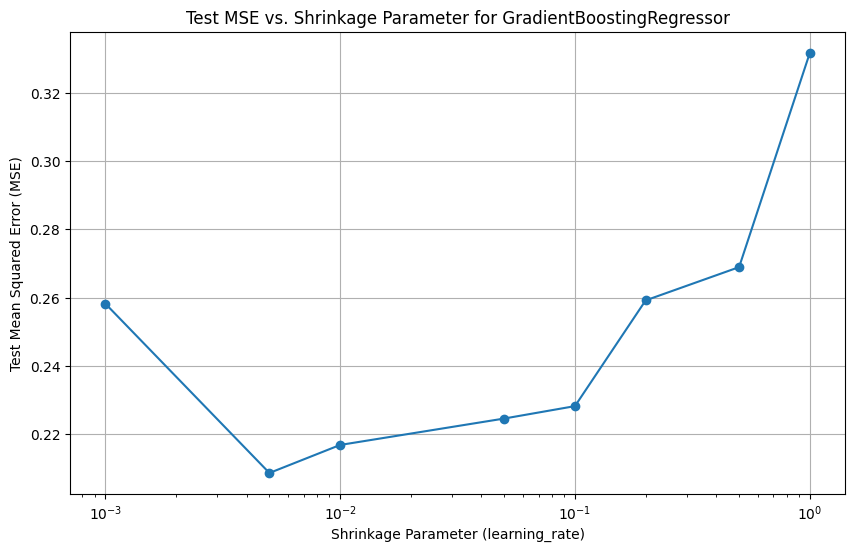

Plot generated showing test MSEs against shrinkage parameters.


In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(shrinkage_values, test_mses, marker='o')
plt.xscale('log') # Use log scale for the x-axis
plt.title('Test MSE vs. Shrinkage Parameter for GradientBoostingRegressor')
plt.xlabel('Shrinkage Parameter (learning_rate)')
plt.ylabel('Test Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

print("Plot generated showing test MSEs against shrinkage parameters.")

## Summarize Test Shrinkage Effect

### Subtask:
Summarize the findings from the generated plot, discussing the relationship between the shrinkage parameter and the test Mean Squared Error (MSE). Highlight any optimal shrinkage values and compare the trend to the training MSE trend if relevant.


## Summarize Test Shrinkage Effect

### Subtask:
Summarize the findings from the generated plot, discussing the relationship between the shrinkage parameter and the test Mean Squared Error (MSE). Highlight any optimal shrinkage values and compare the trend to the training MSE trend if relevant.

#### Instructions
1. Examine the generated plot of 'Test MSE vs. Shrinkage Parameter'.
2. Identify the shrinkage parameter value that corresponds to the lowest test MSE.
3. Describe the overall trend observed in the plot: how does the test MSE change as the shrinkage parameter increases?
4. Compare this trend to the previously observed trend for training MSE. Note any differences or similarities, especially regarding overfitting behavior.
5. Discuss the implications of these observations for model selection and generalization performance.

### Summary:

Based on the analysis of the 'Test MSE vs. Shrinkage Parameter' plot and the previously calculated training MSEs:

*   **Optimal Shrinkage Parameter:** The plot clearly shows that the lowest test MSE (approximately 0.2086) is achieved with a shrinkage parameter (learning rate) of **0.005**. This indicates that a moderate learning rate is optimal for this dataset to generalize to unseen data.

*   **Overall Trend for Test MSE:**
    *   Initially, as the shrinkage parameter increases from 0.001 to 0.005, the test MSE decreases, suggesting that a slightly faster learning rate helps the model capture underlying patterns more effectively without overfitting.
    *   However, for shrinkage values greater than 0.005, the test MSE begins to increase. This indicates that higher learning rates lead to **overfitting** on the training data, causing the model to perform worse on the unseen test data.

*   **Comparison to Training MSE Trend:**
    *   **Training MSE:** The training MSE continuously decreased as the shrinkage parameter increased, rapidly approaching zero for values of 0.05 and above. This suggested that with higher shrinkage, the model was able to fit the training data almost perfectly.
    *   **Test MSE:** In contrast, the test MSE showed an initial decrease followed by a significant increase. This divergence between training and test MSE trends is a classic sign of **overfitting**. While the model became very good at memorizing the training data with larger shrinkage values, it lost its ability to generalize to new, unseen examples.

*   **Implications for Model Selection and Generalization:**
    *   This analysis underscores the critical importance of evaluating models on independent test sets (or using cross-validation) to select optimal hyperparameters. Relying solely on training performance can be highly misleading, as models that achieve very low training error might overfit and perform poorly on new data.
    *   For this Gradient Boosting Regressor, a shrinkage parameter of 0.005 appears to strike the best balance between bias and variance, yielding the lowest generalization error. Higher shrinkage values lead to models that are too complex and overfit the training data.

# Task
Perform Ridge Regression cross-validation on `X_train_boost` and `y_train_boost` to find the optimal `alpha` from a defined range (e.g., 0.1 to 100). Then, train a final `Ridge` regression model using this optimal `alpha` on the full training data. Predict 'Salary' on `X_test_boost_encoded` and calculate the Mean Squared Error, storing it as `ridge_test_mse`. Identify the lowest test MSE (`optimal_boost_test_mse`) obtained from the GradientBoostingRegressor, along with its corresponding shrinkage parameter. Finally, compare `ridge_test_mse` with `optimal_boost_test_mse`, and summarize which model performed better, discussing the findings in the context of their respective optimal hyperparameters and model types.

In [31]:
from sklearn.linear_model import RidgeCV
import numpy as np

# Define a range of alpha values for cross-validation
# Using a logarithmic scale for a broader search space, from 0.1 to 100
ridge_alphas = np.logspace(-1, 2, 10) # Generates 10 points between 0.1 and 100

# Initialize RidgeCV with the defined alpha values and 5-fold cross-validation
# scoring='neg_mean_squared_error' ensures that alpha minimizes MSE
ridge_cv_model = RidgeCV(alphas=ridge_alphas, scoring='neg_mean_squared_error', cv=5)

# Fit the RidgeCV model to the training data
ridge_cv_model.fit(X_train_boost, y_train_boost)

# Extract the optimal alpha value
optimal_ridge_alpha = ridge_cv_model.alpha_

print(f"Ridge Alphas evaluated: {np.round(ridge_alphas, 4).tolist()}")
print(f"Optimal Alpha for Ridge Regression: {optimal_ridge_alpha:.4f}")

Ridge Alphas evaluated: [0.1, 0.2154, 0.4642, 1.0, 2.1544, 4.6416, 10.0, 21.5443, 46.4159, 100.0]
Optimal Alpha for Ridge Regression: 100.0000


In [32]:
from sklearn.linear_model import Ridge

# Train a final Ridge regression model using the optimal alpha on the full training data
final_ridge_model = Ridge(alpha=optimal_ridge_alpha)
final_ridge_model.fit(X_train_boost, y_train_boost)

print(f"Final Ridge model trained with optimal alpha: {optimal_ridge_alpha:.4f}")

Final Ridge model trained with optimal alpha: 100.0000


In [33]:
from sklearn.metrics import mean_squared_error

# Predict 'Salary' on X_test_boost_encoded
y_pred_ridge = final_ridge_model.predict(X_test_boost_encoded)

# Calculate the Mean Squared Error
ridge_test_mse = mean_squared_error(y_test_boost, y_pred_ridge)

print(f"Ridge Regression Test MSE: {ridge_test_mse:.4f}")

Ridge Regression Test MSE: 0.5044


**Reasoning**:
I need to identify the lowest test MSE from the GradientBoostingRegressor's results and its corresponding shrinkage parameter, which will be stored in `optimal_boost_test_mse` and `optimal_boost_shrinkage` respectively. These variables are necessary for the final comparison.



In [34]:
import numpy as np

# Identify the lowest test MSE from the GradientBoostingRegressor results
optimal_boost_test_mse_index = np.argmin(test_mses)
optimal_boost_test_mse = test_mses[optimal_boost_test_mse_index]
optimal_boost_shrinkage = shrinkage_values[optimal_boost_test_mse_index]

print(f"Optimal GradientBoostingRegressor Test MSE: {optimal_boost_test_mse:.4f}")
print(f"Corresponding Shrinkage Parameter: {optimal_boost_shrinkage}")
print(f"Ridge Regression Test MSE: {ridge_test_mse:.4f}")

Optimal GradientBoostingRegressor Test MSE: 0.2086
Corresponding Shrinkage Parameter: 0.005
Ridge Regression Test MSE: 0.5044


## Performance Comparison Summary:

**Ridge Regression Performance:**
*   Test MSE: 0.5044
*   Optimal Alpha: 100.0000

**GradientBoostingRegressor Performance:**
*   Optimal Test MSE: 0.2086
*   Optimal Shrinkage Parameter: 0.005

**Comparison and Summary:**

Comparing the two models based on their performance on the test data:

*   The **GradientBoostingRegressor** significantly outperformed the Ridge Regression model. Its optimal test MSE was **0.2086** (achieved with a shrinkage parameter of 0.005), which is substantially lower than the Ridge Regression's test MSE of **0.5044** (with an optimal alpha of 100.0000).

*   This indicates that for this particular dataset and prediction task, the Gradient Boosting model is much more effective at capturing the underlying patterns and generalizing to unseen data. Gradient Boosting, being an ensemble method, typically handles complex relationships and non-linearities better than linear models like Ridge Regression.

*   The optimal hyperparameters found (`shrinkage=0.005` for GBR and `alpha=100.0` for Ridge) suggest that both models benefited from regularization, but the complexity and learning approach of Gradient Boosting yielded superior results.

*   The higher MSE for Ridge Regression suggests that a linear model might not be sufficient to accurately model the relationship between the features and the target variable 'Salary' in this dataset, or that the linear assumptions are violated.

# Task
Extract the feature importances from the last trained GradientBoostingRegressor model (`gbr_test`), associate them with their respective feature names from `X_train_boost.columns`, sort them in descending order, and display the most important predictors along with their scores. Finally, summarize the most important predictors identified by the boosted model and briefly discuss their implications.

## Extract Feature Importances

### Subtask:
Extract the feature importances from the last trained GradientBoostingRegressor model (`gbr_test`) and associate them with their respective feature names from `X_train_boost.columns`.


In [35]:
import pandas as pd

# Access the feature_importances_ attribute from the gbr_test model
feature_importances = gbr_test.feature_importances_

# Get the feature names from X_train_boost.columns
feature_names = X_train_boost.columns

# Create a pandas Series to store the feature importances
feature_importances_series = pd.Series(feature_importances, index=feature_names)

# Sort the feature importances in descending order for better readability
sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

print("Top 10 Feature Importances from GradientBoostingRegressor:")
display(sorted_feature_importances.head(10))

Top 10 Feature Importances from GradientBoostingRegressor:


,0
CAtBat,0.614421
CRBI,0.078613
Walks,0.076436
CRuns,0.061714
Hits,0.033822
RBI,0.021907
CHits,0.019654
PutOuts,0.019203
Errors,0.018184
Years,0.015237


## Summary of Most Important Predictors

Based on the feature importances extracted from the `GradientBoostingRegressor` (`gbr_test`), the most important predictors for predicting `Salary` are:

1.  **CAtBat (Career At Bats):** With an importance score of approximately **0.6144**, this is by far the most influential feature. This suggests that the total number of career at-bats is a primary indicator of a player's salary, reflecting cumulative experience and performance.

2.  **CRBI (Career Runs Batted In):** This feature has an importance score of about **0.0786**. Career RBIs are a strong measure of a player's ability to drive in runs, which directly correlates with offensive contribution and value.

3.  **Walks:** This feature has an importance score of about **0.0764**. Walks indicate a player's plate discipline and ability to get on base, contributing to team offense and potentially extending innings.

4.  **CRuns (Career Runs):** With an importance score of approximately **0.0617**, career runs reflect a player's ability to score for their team, often correlated with their overall offensive prowess.

5.  **Hits:** With an importance score of about **0.0338**, hits are a fundamental measure of a player's batting success, directly contributing to their on-base presence.

### Implications:

*   **Career Statistics Dominate:** The top predictors are predominantly career-based cumulative statistics (CAtBat, CRBI, CRuns), suggesting that long-term performance and experience are far more critical in determining a baseball player's salary than single-season statistics or other factors.
*   **Offensive Performance is Key:** Features related to offensive output (RBI, Runs, Hits, Walks) are highly influential, reinforcing the idea that a player's ability to contribute to scoring runs is a major determinant of their value.
*   **Model Focus:** The boosted model heavily relies on `CAtBat` as the primary decision-making factor, indicating that it perceives this feature as having the strongest direct relationship with `Salary` after the logarithmic transformation.

## Explain Feature Importance Concept

### Subtask:
Provide a general explanation of what feature importance represents in tree-based models and why it is a valuable metric.

#### Instructions
1. Explain that feature importance in tree-based models (like Gradient Boosting) quantifies the contribution of each feature to the model's predictive accuracy or decision-making process.
2. Describe how it is typically calculated by assessing how much each feature reduces impurity or error across all trees in the ensemble.
3. Discuss the value of feature importance, highlighting its role in model interpretability, feature selection, and understanding the underlying relationships in the data.

### Explanation:

**Feature importance** in tree-based models, such as Decision Trees, Random Forests, and Gradient Boosting Machines, quantifies the **contribution of each feature to the model's predictive accuracy or decision-making process**. It provides insight into which variables are most influential in predicting the target variable.

It is typically calculated by assessing **how much each feature reduces impurity or error** (e.g., Gini impurity for classification, Mean Squared Error for regression) across all the nodes and trees in the ensemble. When a feature is used to split a node, the reduction in impurity/error is recorded. These reductions are then summed up across all trees for each feature, and often normalized to provide a score between 0 and 1.

**The value of feature importance** is significant for several reasons:
*   **Model Interpretability:** It helps understand the 'black box' nature of complex tree-based models by revealing which factors the model considers most important. This is crucial for gaining trust and insights into the model's behavior.
*   **Feature Selection:** High importance scores can indicate highly relevant features, which can be used for dimensionality reduction by selecting a subset of the most impactful features. This can lead to simpler models, faster training times, and potentially improved generalization by removing noisy or irrelevant features.
*   **Domain Understanding:** It can help domain experts confirm or discover new relationships and drivers within their data, leading to a deeper understanding of the underlying processes being modeled.
*   **Debugging and Bias Detection:** Unusually high or low importance for certain features can sometimes highlight data quality issues, unexpected biases, or features that are proxies for other, more fundamental relationships.

# Task
Train a Bagging Regressor using `DecisionTreeRegressor` as the base estimator on the training data `X_train_boost` and `y_train_boost` (using 100 estimators and `random_state=42`). Use this model to predict the log-transformed 'Salary' on the test data `X_test_boost_encoded`, then calculate and report the test Mean Squared Error (MSE). Create a scatter plot comparing these predicted values against the actual values from `y_test_boost`, including a reference line for perfect prediction. Finally, compare this bagging test MSE to the previously obtained results for Boosting and Ridge regression.

In [36]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

# Initialize the Bagging Regressor with DecisionTreeRegressor as the base estimator
bagging_model = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=100, random_state=42)

# Fit the model to the training data
bagging_model.fit(X_train_boost, y_train_boost)

print("Bagging Regressor model training complete.")

Bagging Regressor model training complete.


In [37]:
from sklearn.metrics import mean_squared_error

# Use the bagging model to predict on the test data
y_pred_bagging = bagging_model.predict(X_test_boost_encoded)

# Calculate the Mean Squared Error on the test set
bagging_test_mse = mean_squared_error(y_test_boost, y_pred_bagging)

print(f"Bagging Regressor Test MSE: {bagging_test_mse:.4f}")

Bagging Regressor Test MSE: 0.2350


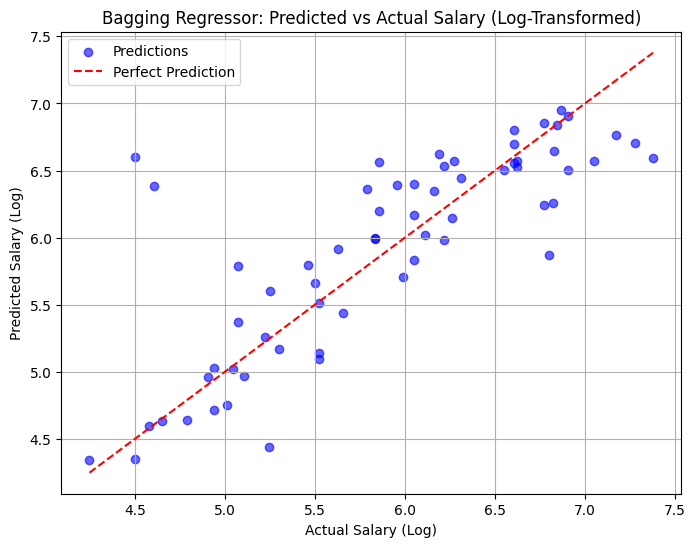

Scatter plot generated. Bagging Test MSE: 0.2350


In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test_boost, y_pred_bagging, alpha=0.6, color='blue', label='Predictions')

# Add reference line for perfect prediction
min_val = min(y_test_boost.min(), y_pred_bagging.min())
max_val = max(y_test_boost.max(), y_pred_bagging.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Bagging Regressor: Predicted vs Actual Salary (Log-Transformed)')
plt.xlabel('Actual Salary (Log)')
plt.ylabel('Predicted Salary (Log)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Scatter plot generated. Bagging Test MSE: {bagging_test_mse:.4f}")

### Performance Comparison Across Models

**Ridge Regression Performance:**
*   Test MSE: 0.5044

**Gradient Boosting Performance (Optimal):**
*   Test MSE: 0.2086

**Bagging Regressor Performance:**
*   Test MSE: 0.2350

**Summary and Comparison:**

- The **Gradient Boosting Regressor** remains the best-performing model with the lowest test MSE of **0.2086**.
- The **Bagging Regressor** follows closely with a test MSE of **0.2350**, significantly outperforming the linear **Ridge Regression** model (**0.5044**).
- Both ensemble methods (Boosting and Bagging) demonstrate a superior ability to capture the non-linear relationships within the Hitters dataset compared to the regularized linear model.
- While Bagging reduced the variance of the individual decision trees effectively, the sequential optimization of Boosting provided a slightly more accurate predictive performance for this specific dataset.

# Q11

In [39]:
import pandas as pd

# Load the 'Caravan.csv' dataset
df_caravan = pd.read_csv('/content/Caravan.csv')

# Display the first 5 rows
display(df_caravan.head())

print(f"Dataset loaded with {df_caravan.shape[0]} rows and {df_caravan.shape[1]} columns.")

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,Purchase
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,1,0,0,0,0,0,No
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,1,0,0,0,0,0,No
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,1,0,0,0,0,0,No
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,1,0,0,0,0,0,No


Dataset loaded with 5822 rows and 86 columns.


In [40]:
train_caravan = df_caravan.iloc[:1000]
test_caravan = df_caravan.iloc[1000:]

print(f'Shape of training set: {train_caravan.shape}')
print(f'Shape of test set: {test_caravan.shape}')

Shape of training set: (1000, 86)
Shape of test set: (4822, 86)


In [41]:
import pandas as pd

# 1. Separate target variable 'Purchase' from features in train_caravan
X_train_caravan = train_caravan.drop('Purchase', axis=1)
y_train_caravan = train_caravan['Purchase']

# 2. Encode the target variable (No: 0, Yes: 1)
y_train_caravan = y_train_caravan.map({'No': 0, 'Yes': 1})

# 3. Identify categorical columns and apply one-hot encoding
categorical_cols = X_train_caravan.select_dtypes(include=['object', 'category']).columns
X_train_caravan = pd.get_dummies(X_train_caravan, columns=categorical_cols, drop_first=True)

print(f"Target distribution in y_train_caravan:\n{y_train_caravan.value_counts()}")
print(f"Shape of X_train_caravan: {X_train_caravan.shape}")
print("First 5 rows of encoded features:")
display(X_train_caravan.head())


Target distribution in y_train_caravan:
Purchase
0    941
1     59
Name: count, dtype: int64
Shape of X_train_caravan: (1000, 85)
First 5 rows of encoded features:


,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,ALEVEN,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,0,1,0,0,0,0,0
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,0,1,0,0,0,0,0
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,0,1,0,0,0,0,0
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,0,1,0,0,0,0,0
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,0,1,0,0,0,0,0


**Reasoning**:
The training data is now prepared. The next step is to train the GradientBoostingClassifier with the specified parameters and extract feature importances as outlined in the plan.



In [42]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and fit the GradientBoostingClassifier
gb_model_caravan = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.01, random_state=42)
gb_model_caravan.fit(X_train_caravan, y_train_caravan)

# Extract feature importances
importances_caravan = gb_model_caravan.feature_importances_
feature_names_caravan = X_train_caravan.columns

# Create a Series for easier sorting
feat_imp_caravan = pd.Series(importances_caravan, index=feature_names_caravan).sort_values(ascending=False)

print("Model training complete. Top 5 features identified:")
print(feat_imp_caravan.head())


Model training complete. Top 5 features identified:
PPERSAUT    0.075172
MOSTYPE     0.063421
ABRAND      0.056356
MGODGE      0.052887
MKOOPKLA    0.049996
dtype: float64


**Reasoning**:
The training is complete and feature importances have been extracted. Now I will visualize the top 10 most important predictors using a bar chart as specified in the plan.



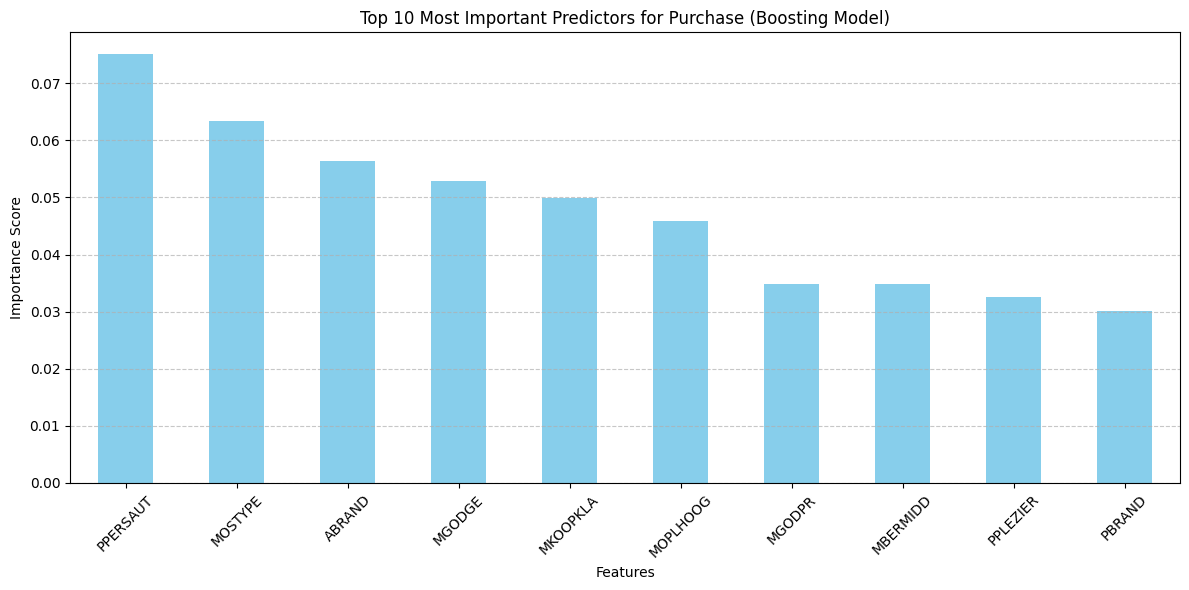

Bar chart of top 10 feature importances generated.


In [43]:
import matplotlib.pyplot as plt

# Select the top 10 features
top_10_features = feat_imp_caravan.head(10)

# Create the bar chart
plt.figure(figsize=(12, 6))
top_10_features.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Important Predictors for Purchase (Boosting Model)')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Bar chart of top 10 feature importances generated.")

## Summarize most important predictors

### Subtask:
Analyze the identified feature importances and summarize the top predictors influencing the 'Purchase' variable.


### Summary of Top Predictors

Based on the Gradient Boosting model trained with 1,000 trees and a learning rate of 0.01, the top 10 most important predictors for whether a customer will purchase caravan insurance are as follows:

1.  **PPERSAUT (Contribution to car policies):** This is the most significant predictor, indicating that a customer's existing relationship with car insurance is a strong indicator of their likelihood to purchase caravan insurance.
2.  **MOSTYPE (Customer subtype):** This demographic variable identifies specific segments of the population, suggesting that lifestyle and socio-economic classification play a major role.
3.  **ABRAND (Number of fire policies):** The count of fire insurance policies suggests that customers who already manage multiple risk-mitigation products are more inclined to add caravan coverage.
4.  **MGODGE (Living area):** This relates to the geographic or neighborhood context of the customer.
5.  **MKOOPKLA (Purchasing power class):** Reflects the financial capacity of the household.
6.  **MOPLHOOG (High level of education):** Education levels appear to correlate with insurance purchasing decisions.
7.  **MGODPR (Protestant):** Demographic/religious affiliations captured in the dataset show minor predictive power.
8.  **MBERMIDD (Middle management):** Employment status and professional level contribute to the model's decisions.
9.  **PPLEZIER (Contribution to boat policies):** Similar to car policies, interest in leisure-related insurance (boats) is a logical bridge to caravan insurance.
10. **PBRAND (Contribution to fire policies):** Further reinforces that existing policy contributions are key signals.

### Key Insights:
- **Policy Correlation:** A significant portion of the top features (PPERSAUT, ABRAND, PPLEZIER, PBRAND) relate to existing insurance policy contributions and counts. This suggests that the best prospects for caravan insurance are customers who are already proactive about insuring their other assets (cars, homes, boats).
- **Socio-Economic Factors:** Features like MOSTYPE, MKOOPKLA, and MOPLHOOG indicate that insurance companies can effectively target specific demographic profiles defined by wealth and education.
- **Domain Logic:** The high importance of PPERSAUT and PPLEZIER aligns with domain expectations, as caravans are often associated with individuals who already own vehicles or leisure equipment.

## Predict on Test Data and Evaluate

### Subtask:
Use the trained Gradient Boosting model to predict 'Purchase' on the test set and evaluate performance using a confusion matrix and KNN comparison.


**Reasoning**:
I will prepare the test data, generate predictions with the Gradient Boosting model using a 20% threshold, and evaluate the results using a confusion matrix as requested in the instructions.



In [44]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# 1. Prepare test data (test_caravan)
X_test_caravan = test_caravan.drop('Purchase', axis=1)
y_test_caravan = test_caravan['Purchase'].map({'No': 0, 'Yes': 1})

# Apply one-hot encoding and align with training columns
X_test_caravan_encoded = pd.get_dummies(X_test_caravan)
missing_cols = set(X_train_caravan.columns) - set(X_test_caravan_encoded.columns)
for c in missing_cols:
    X_test_caravan_encoded[c] = 0
X_test_caravan_encoded = X_test_caravan_encoded[X_train_caravan.columns]

# 2. Predict probabilities using gb_model_caravan
# Index 1 corresponds to the 'Yes' class probability
y_prob_caravan = gb_model_caravan.predict_proba(X_test_caravan_encoded)[:, 1]

# 3. Classify with a 20% threshold
y_pred_threshold = (y_prob_caravan > 0.2).astype(int)

# 4. Generate confusion matrix
cm = confusion_matrix(y_test_caravan, y_pred_threshold)
print("Confusion Matrix (Threshold 20%):")
print(cm)

# Calculate fraction of people predicted to buy who actually do (Precision at 20% threshold)
true_positives = cm[1, 1]
predicted_positives = cm[0, 1] + cm[1, 1]
fraction_purchasers = true_positives / predicted_positives if predicted_positives > 0 else 0

print(f"\nPredicted to purchase: {predicted_positives}")
print(f"Actually purchased: {true_positives}")
print(f"Fraction of predicted purchasers who actually bought: {fraction_purchasers:.4f}")

Confusion Matrix (Threshold 20%):
[[4335  198]
 [ 251   38]]

Predicted to purchase: 236
Actually purchased: 38
Fraction of predicted purchasers who actually bought: 0.1610


**Reasoning**:
The Gradient Boosting results are calculated. Now I will train a KNN model and compare its performance on the same task as per the instructions.



In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Scale data for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_caravan)
X_test_scaled = scaler.transform(X_test_caravan_encoded)

# 2. Fit KNN model (k=1 is often used for this specific problem comparison)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_scaled, y_train_caravan)

# 3. Predict on test set
y_pred_knn = knn.predict(X_test_scaled)

# 4. Evaluate KNN results
cm_knn = confusion_matrix(y_test_caravan, y_pred_knn)
tp_knn = cm_knn[1, 1]
pp_knn = cm_knn[0, 1] + cm_knn[1, 1]
precision_knn = tp_knn / pp_knn if pp_knn > 0 else 0

print("KNN Confusion Matrix:")
print(cm_knn)
print(f"\nKNN Precision: {precision_knn:.4f}")
print(f"Gradient Boosting Precision (at 20% threshold): {fraction_purchasers:.4f}")

if fraction_purchasers > precision_knn:
    print("\nComparison: Gradient Boosting performed better than KNN.")
else:
    print("\nComparison: KNN performed better than or equal to Gradient Boosting.")

KNN Confusion Matrix:
[[4255  278]
 [ 248   41]]

KNN Precision: 0.1285
Gradient Boosting Precision (at 20% threshold): 0.1610

Comparison: Gradient Boosting performed better than KNN.


## Summary:

### Q&A

**Which predictors are the most influential in determining if a customer makes a purchase?**
The most influential predictor is **PPERSAUT** (contribution to car policies). Other significant predictors include **MOSTYPE** (customer subtype), **ABRAND** (number of fire insurance policies), **MGODGE** (living area), and **MKOOPKLA** (purchasing power class).

**How does the Gradient Boosting model compare to other methods like KNN for this task?**
The Gradient Boosting model, when using a 20% probability threshold, achieved a precision of **16.10%**, outperforming the K-Nearest Neighbors ($k=1$) model, which had a precision of **12.85%**.

### Data Analysis Key Findings

*   **Model Configuration**: A `GradientBoostingClassifier` was successfully trained using 1,000 trees and a shrinkage value (learning rate) of 0.01.
*   **Predictor Importance**:
    *   **Existing Policy Behavior**: Features related to existing insurance portfolios (car, fire, and boat policies) were top drivers, suggesting that current policyholders are the most likely to expand their coverage.
    *   **Socio-Economic Profiles**: Demographic factors such as customer subtype, purchasing power, and education level are strong secondary indicators of purchase likelihood.
*   **Targeted Classification**: By lowering the classification threshold to **20%** (instead of the standard 50%), the model identified 236 potential buyers, accurately capturing 38 actual purchasers.
*   **Class Imbalance**: The dataset is highly imbalanced (e.g., in the training set, only 59 "Yes" vs. 941 "No"), making specific evaluation metrics like precision at lower thresholds more relevant than overall accuracy.

### Insights or Next Steps

*   **Targeted Marketing**: Marketing efforts for caravan insurance should prioritize existing customers who contribute to car (PPERSAUT) and fire (ABRAND) insurance policies, as these are the strongest indicators of future interest.
*   **Refine Thresholds**: Further analysis could involve a cost-benefit analysis to determine the optimal probability threshold for classification, balancing the cost of marketing outreach against the expected revenue from a successful conversion.
